# Get Files Prepped for LIET
This is being done after a first round with the 8,500 enhancer responses of UPM or ADP (I accidentally read in UPM for WSP).
The initial LIET results showed that a small subset of the regions had 95th percentiles extending beyond the padded regions, suggesting that there was a nearby enhancer whose transcription was not fully hidden.

Therefore, the changes in this notebook will include:
1. Get the regions for all UPM and ADP and WSP instead of just UPM and ADP, excluding calls that were already fine
2. Edit the paddings of RNAs where the 95th percentile calls were greater than the padding
3. Ensure a cleaner version of the coverage filter instead of just 0.

In [1]:
library(data.table)
library(stringr)

## 1. Get the NonTSS Calls

In [2]:
mus <- fread("/Users/hoto7260/projects/Resp_Env/Comb_UPM_WSP_ADP/mumerge/out/UPM_WSP_ADP_tfit_MUMERGE.bed")
mus[1:2,]
mus$mu <- as.integer((mus$V2 + mus$V3)/2)
mus$Name <- paste0(mus$V1, ":", mus$mu)

V1,V2,V3,V4
<chr>,<int>,<int>,<chr>
chr1,629230,629302,APM_sm1_1;APM_sm1_2;VEH_sm1_1;VEH_sm1_2
chr1,629882,629968,APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2


In [3]:
tss <- fread("/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/ADP/regions/tss_bid_CUWA_ADP_3.26.25.txt")
tss[1:3,]
tss$Name <- paste0(tss$Chr, ":", tss$mu)
tss <- tss$Name
tss[1:4]

Chr,Bid_Start,Bid_Stop,BidID,Gene_Start,Gene_Stop,TranscriptID,Strand,mu,TSS,GeneID
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>
chr1,629241,629291,chr1:629230-629302,628509,629509,LOC101928626:NR_125957.1,-,629266,629009,LOC101928626
chr1,632659,632709,chr1:632605-632763,632185,633185,MIR12136:NR_162149.1,-,632684,632685,MIR12136
chr1,778691,778741,chr1:778521-778911,778134,779134,LOC100288069:NR_168328.1,-,778716,778634,LOC100288069


[1] "chr1:629266" "chr1:632684" "chr1:778716" "chr1:778716"

In [4]:
nontss_mus <- mus[!mus$Name %in% tss,]
dim(mus)
dim(nontss_mus)

[1] 85021     6

[1] 64366     6

In [5]:
# make the LIET file
LIET_mu <- data.frame(data.table("chr"= nontss_mus$V1, 
                              "start"=as.integer(nontss_mus$mu), 
                             "end"=as.integer(nontss_mus$mu)+200, 
                              "name"=nontss_mus$Name,
                              "length"=rep(200, nrow(nontss_mus)),
                             "strand"="+"))
LIET_mu[1:2,]
# Save it
LIET_input_dir = "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/LIET/LIET_input/"
write.table(LIET_mu, paste0(LIET_input_dir, "LIETinput_CUWA_05.8.25.txt"), 
           row.names=FALSE, col.names=FALSE, sep="\t", quote=FALSE)

,chr,start,end,name,length,strand
,<chr>,<int>,<dbl>,<chr>,<dbl>,<chr>
1,chr1,629925,630125,chr1:629925,200,+
2,chr1,631361,631561,chr1:631361,200,+


## 2. Get Pad Files for Calls
- See if any bids within 3kb of another bid --> change padding to reflect that
1. Do bedtools closest with bids, not including those with the same name
2. For each bid, if something within 3kb, use the MUDIFF as the new pad
* Pad file format is name"\t"left_pad, right_pad (e.g RPL22|NM_000983.4	5000, 25000)

In [7]:
closest <- fread("closest_downstream_bid.bed")
closest[1:4,]
# only consider those where < 3kb
cat("\nDistances working with:", quantile(closest$V9))
dim(closest)
dim(closest[closest$V9 < 0,])
closest[closest$V9 < 0,]
closest <- closest[abs(closest$V9) < 3000 & closest$V9 != -1,]
dim(closest)
cat("\nDistances working with:", quantile(closest$V9))

V1,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>
chr1,629266,629267,chr1:629266:APM_sm1_1;APM_sm1_2;VEH_sm1_1;VEH_sm1_2,chr1,629925,629926,chr1:629925:APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,659
chr1,629925,629926,chr1:629925:APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,chr1,631361,631362,chr1:631361:APM_sm1_1;VEH_sm1_1;VEH_sm1_2,1436
chr1,631361,631362,chr1:631361:APM_sm1_1;VEH_sm1_1;VEH_sm1_2,chr1,632426,632427,chr1:632426:VEH_sm1_2,1065
chr1,632426,632427,chr1:632426:VEH_sm1_2,chr1,632684,632685,chr1:632684:APM_sm1_1;APM_sm1_2;VEH_sm1_1;VEH_sm1_2,258



Distances working with: -1 1275 4813 22265 21837217

[1] 85021     9

[1] 24  9

V1,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>
chr1,248932220,248932221,chr1:248932220:VEH_sm36_1,.,-1,-1,.,-1
chr10,133541640,133541641,chr10:133541640:UPM30_sm36_2,.,-1,-1,.,-1
chr11,134950889,134950890,chr11:134950889:WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,.,-1,-1,.,-1
chr12,133181513,133181514,chr12:133181513:VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,.,-1,-1,.,-1
chr13,114344064,114344065,chr13:114344064:WSP30_B2B_1;WSP30_B2B_2,.,-1,-1,.,-1
chr14,106848494,106848495,chr14:106848494:VEH_sm1_2,.,-1,-1,.,-1
chr15,101962862,101962863,chr15:101962862:UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_sm36_1;VEH_sm36_2,.,-1,-1,.,-1
chr16,90107174,90107175,chr16:90107174:APM_sm1_1;UPM120_sm36_1;UPM120_sm36_2;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2,.,-1,-1,.,-1
chr17,83237660,83237661,chr17:83237660:WSP30_B2B_1;WSP30_B2B_2,.,-1,-1,.,-1


[1] 35080     9


Distances working with: 59 699 1058 1701 2999

In [8]:
closest[1:2,]
split <- str_split_fixed(closest$V4, ":", 3)
closest$left_most_name <- paste0(split[,1], ":", split[,2])
closest$left_sources <- split[,3]
split <- str_split_fixed(closest$V8, ":", 3)
closest$right_most_name <- paste0(split[,1], ":", split[,2])
closest$right_sources <- split[,3]
closest[1:2,]

V1,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>
chr1,629266,629267,chr1:629266:APM_sm1_1;APM_sm1_2;VEH_sm1_1;VEH_sm1_2,chr1,629925,629926,chr1:629925:APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,659
chr1,629925,629926,chr1:629925:APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,chr1,631361,631362,chr1:631361:APM_sm1_1;VEH_sm1_1;VEH_sm1_2,1436


V1,V2,V3,V4,V5,V6,V7,V8,V9,left_most_name,left_sources,right_most_name,right_sources
<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,629266,629267,chr1:629266:APM_sm1_1;APM_sm1_2;VEH_sm1_1;VEH_sm1_2,chr1,629925,629926,chr1:629925:APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,659,chr1:629266,APM_sm1_1;APM_sm1_2;VEH_sm1_1;VEH_sm1_2,chr1:629925,APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2
chr1,629925,629926,chr1:629925:APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,chr1,631361,631362,chr1:631361:APM_sm1_1;VEH_sm1_1;VEH_sm1_2,1436,chr1:629925,APM_sm1_1;APM_sm1_2;UPM120_sm36_1;UPM120_sm36_2;UPM30_sm36_1;UPM30_sm36_2;VEH_B2B_1;VEH_B2B_2;VEH_sm1_1;VEH_sm1_2;VEH_sm36_1;VEH_sm36_2;WSP120_B2B_1;WSP120_B2B_2;WSP30_B2B_1;WSP30_B2B_2,chr1:631361,APM_sm1_1;VEH_sm1_1;VEH_sm1_2


In [9]:
# Create a pad file for all NonTSS bids where the initial is -3000,3000
# and then consider the maximum distance to the next mu. If it is less than 500, just keep 500
pad_file = data.frame(data.table("Name"=nontss_mus$Name, "Left"=rep(3000, nrow(nontss_mus)), 
                                "Right"=rep(3000, nrow(nontss_mus))))
# For each pair where there is a problem
for (indx in seq(1, nrow(closest))) {
    # get the distance between the two
    distance = closest$V9[indx]
    left_most_name = closest$left_most_name[indx]
    right_most_name = closest$right_most_name[indx]
    # replace the leftmost bid with the shorter right pad
    if (left_most_name %in% pad_file$Name) {
        pad_file[pad_file$Name == left_most_name,]$Right <- distance }
    # replace the rightmost bid with the shorter left pad
    if (right_most_name %in% pad_file$Name) {
        pad_file[pad_file$Name == right_most_name,]$Left <- distance }
    }
cat("\nNumber where Left < 3000", nrow(pad_file[pad_file$Left != 3000,]), 
        "\nNumber where Right < 3000", nrow(pad_file[pad_file$Right != 3000,]), 
        "\nNumber were both sides < 3000", nrow(pad_file[pad_file$Left != 3000 & pad_file$Right !=3000,]))


Number where Left < 3000 25814 
Number where Right < 3000 26269 
Number were both sides < 3000 9846

In [11]:
quantile(pad_file$Right)
quantile(pad_file$Left)
pad_file$pad <- paste0(pad_file$Left, ", ", pad_file$Right)

# save pad file
write.table(pad_file[,c("Name", "pad")], paste0(LIET_input_dir, "Pad_file_05.15.25.txt"), 
            quote=FALSE, sep="\t", row.names=FALSE, col.names=FALSE)

0%  25%  50%  75% 100% 
  78 1388 3000 3000 3000

0%  25%  50%  75% 100% 
  78 1424 3000 3000 3000

### 2B. Make more conservative padding for regions with lengths extending beyond pads

chr,start,end,name,LIET_coverage,strand,mu,length,name,L_pad,gene
<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>
chr10,100311494,100312121,chr10:100311438|+,23,+,100311438,627,chr10:100311438|+,500,chr10:100311438
chr10,100346568,100347957,chr10:100346521|+,973,+,100346521,1389,chr10:100346521|+,500,chr10:100346521


[1] 1681   11

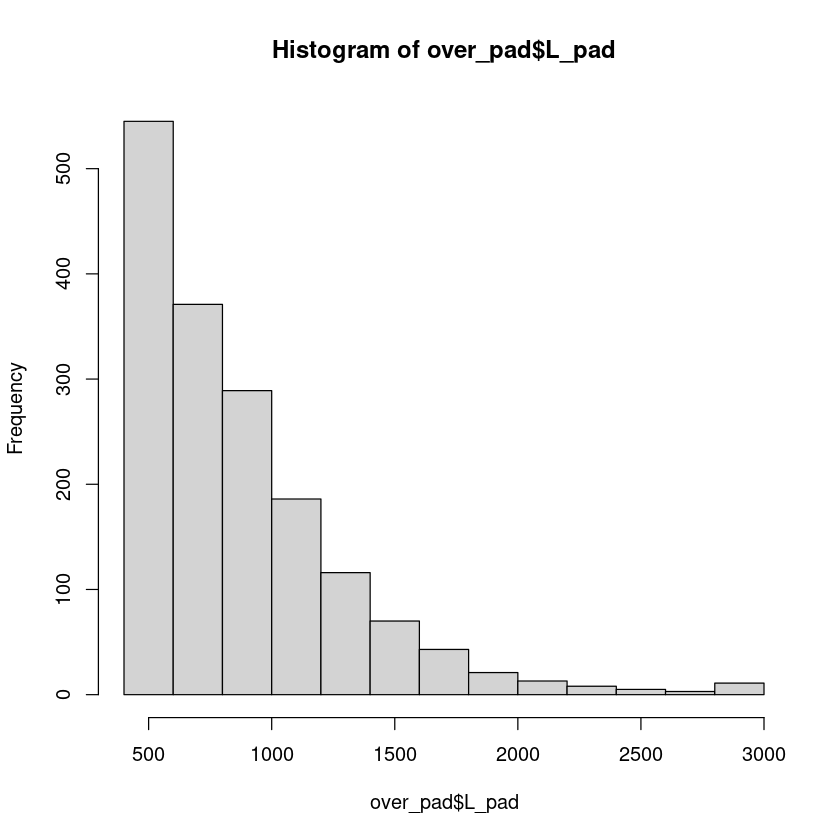

In [13]:
over_pad <- fread("./LIET_OVERpad_95thperc_8500_5.8.25.txt")
over_pad$gene <- str_split_fixed(over_pad$name, "[|]", 2)[,1]
over_pad[1:2,]
dim(over_pad)
hist(over_pad$L_pad)

In [18]:
length(intersect(over_pad$name, pad_file$Name))

[1] 0

In [19]:
# if they already have less than 300 then don't change anything
less_300_left = paste0(pad_file[pad_file$Left < 300,]$Name, "|-")
less_300_right = paste0(pad_file[pad_file$Right < 300,]$Name, "|+")
length(union(less_300_left, less_300_right))
over_pad = over_pad[!over_pad$name %in% union(less_300_left, less_300_right),]
dim(over_pad)

[1] 615

[1] 1606   11

In [22]:
## For a start, just lower the pad by 200 for all of them
left_decrease = over_pad[over_pad$strand == "-",]
dim(left_decrease)
right_decrease = over_pad[over_pad$strand == "+",]
dim(right_decrease)
pad_file[1:2,]

pad_file$New_left = pad_file$Left
pad_file$New_right = pad_file$Right
pad_file[pad_file$Name %in% left_decrease$gene,]$New_left = pad_file[pad_file$Name %in% left_decrease$gene,]$Left - 200
pad_file[pad_file$Name %in% right_decrease$gene,]$New_right = pad_file[pad_file$Name %in% right_decrease$gene,]$Right - 200

dim(pad_file[pad_file$New_right != pad_file$Right,])
dim(pad_file[pad_file$New_left != pad_file$Left,])

[1] 605  11

[1] 1001   11

,Name,Left,Right,pad,New_left,New_right
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,chr1:629925,659,1436,"659, 1436",659,1436
2,chr1:631361,1436,1065,"1436, 1065",1436,1065


[1] 1001    6

[1] 605   6

In [23]:
pad_file[1:2,]
pad_file$Pad = paste0(pad_file$New_left, ", ", pad_file$New_right)
pad_file[1:2,]

,Name,Left,Right,pad,New_left,New_right
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,chr1:629925,659,1436,"659, 1436",659,1436
2,chr1:631361,1436,1065,"1436, 1065",1436,1065


,Name,Left,Right,pad,New_left,New_right,Pad
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,chr1:629925,659,1436,"659, 1436",659,1436,"659, 1436"
2,chr1:631361,1436,1065,"1436, 1065",1436,1065,"1436, 1065"


In [25]:
write.table(pad_file[,c("Name", "Pad")],
            paste0(LIET_input_dir, "Pad_file_05.15.25.txt"), sep="\t", 
                 row.names=FALSE, col.names=FALSE, quote=FALSE)

## 3. Get the appropriate Files for the Differentially transcribed calls
In this case I'm only keeping those DIFF Exp AND I'm also getting a file only including those not already successfully run

### ALL significant changes (for ADP)

In [40]:
sig_change <- fread("TRE_SIGADPWSPUPM_100bp.bed")
sig_change[1:2,]
sig_change$mu <- as.integer((sig_change$V2 + sig_change$V3)/2)
sig_change$name <- paste0(sig_change$V1, ":", sig_change$mu)
sig_change[1:2,]
dim(sig_change)

V1,V2,V3,V4,V5
<chr>,<int>,<int>,<chr>,<chr>
chr5,53288540,53288640,chr5:53288231-53288949,up_adp
chr22,37545455,37545555,chr22:37545127-37545883,up_adp


V1,V2,V3,V4,V5,mu,name
<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>
chr5,53288540,53288640,chr5:53288231-53288949,up_adp,53288590,chr5:53288590
chr22,37545455,37545555,chr22:37545127-37545883,up_adp,37545505,chr22:37545505


[1] 15196     7

In [41]:
LIET_mu[1:2,]
length(intersect(LIET_mu$name, sig_change$name))
LIET_mu_filt = LIET_mu[LIET_mu$name %in% sig_change$name,]
dim(LIET_mu_filt)
write.table(LIET_mu_filt, paste0(LIET_input_dir, "LIETinput_CUWA_15000SIG_05.14.25.txt"), 
           row.names=FALSE, col.names=FALSE, sep="\t", quote=FALSE)

,chr,start,end,name,length,strand
,<chr>,<int>,<dbl>,<chr>,<dbl>,<chr>
1,chr1,629925,630125,chr1:629925,200,+
2,chr1,631361,631561,chr1:631361,200,+


[1] 15196

[1] 15196     6

### Significant changes not already called in WSP and ADP or with poor pads

In [43]:
# read in the regions already called
done <- fread("./LIET_pad_95thperc_8500_5.8.25.txt")
done[1:2,]
done$gene <- str_split_fixed(done$name, "[|]", 2)[,1]

dim(LIET_mu_filt)
LIET_mu_filtfilt = LIET_mu_filt[!LIET_mu_filt$name %in% done$gene,]
dim(LIET_mu_filtfilt)

chr,start,end,name,LIET_coverage,strand,mu,length,name,L_pad
<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>
chr10,100191667,100192157,chr10:100191659|+,46,+,100191659,490,chr10:100191659|+,3000
chr10,100191409,100191676,chr10:100191659|-,4,-,100191659,267,chr10:100191659|-,3000


[1] 15196     6

[1] 6962    6

In [45]:
# add back regions with changed pads
LIET_mu_filtoverpad = LIET_mu_filt[LIET_mu_filt$name %in% over_pad$gene,]
dim(LIET_mu_filtoverpad)

LIET_mu_filtfilt <- rbind(LIET_mu_filtoverpad, LIET_mu_filtfilt)
dim(LIET_mu_filtfilt)

[1] 1669    6

[1] 8631    6

In [46]:
write.table(LIET_mu_filtfilt, paste0(LIET_input_dir, "LIETinput_CUWA_missed8631SIG_05.14.25.txt"), 
           row.names=FALSE, col.names=FALSE, sep="\t", quote=FALSE)

### Sort the files so that they have the right order expected for LIET (just in case): chr1 --> chr10 --> chr11, etc.

In [ ]:
bedtools sort -i LIETinput_CUWA_missed8631SIG_05.14.25.txt > LIETinput_CUWA_missed8631SIG_05.14.25.sorted.txt
rm LIETinput_CUWA_missed8631SIG_05.14.25.txt
bedtools sort -i LIETinput_CUWA_15000SIG_05.14.25.txt > LIETinput_CUWA_15000SIG_05.14.25.sorted.txt